In [1]:
import warnings



In [2]:
warnings.filterwarnings("ignore")



In [3]:
import pandas as pd


In [4]:
import numpy as np



In [5]:
# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"


In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)



In [8]:
# Extract standard continuous features
X_pima = pima_df[pima_cols[:-1]]


In [9]:
y_pima = pima_df['Outcome']



In [10]:
print("Pima Dataset Shape (rows, cols):", pima_df.shape)


Pima Dataset Shape (rows, cols): (768, 9)


In [11]:
print("\nClass Outcome Distribution:")



Class Outcome Distribution:


In [12]:
print(pima_df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split


In [14]:
from sklearn.ensemble import RandomForestClassifier


In [15]:
from sklearn.metrics import accuracy_score



In [16]:
# Perform Stratified Train-Test Split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)



In [17]:
# Train a baseline Random Forest Classifier
rf_baseline = RandomForestClassifier(random_state=42)


In [18]:
rf_baseline.fit(X_train_p, y_train_p)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Evaluate holdout test accuracy
holdout_preds = rf_baseline.predict(X_test_p)


In [20]:
holdout_accuracy = accuracy_score(y_test_p, holdout_preds)



In [21]:
print(f"Stratified Holdout (Train-Test Split) Accuracy: {holdout_accuracy * 100:.2f}%")

Stratified Holdout (Train-Test Split) Accuracy: 75.97%


In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score



In [23]:
# Initialize 10-Fold Stratified CV Strategy
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)



In [24]:
# Compute cross-validation scores using baseline Random Forest
cv_scores = cross_val_score(rf_baseline, X_pima, y_pima, cv=cv_strategy, scoring='accuracy')



In [25]:
print("10-Fold Stratified CV Accuracy Scores:")


10-Fold Stratified CV Accuracy Scores:


In [26]:
print(cv_scores.round(4))


[0.8052 0.7532 0.7143 0.8701 0.7922 0.7273 0.7532 0.7662 0.7895 0.7237]


In [27]:
print(f"\nMean Cross-Validation Accuracy Score: {cv_scores.mean() * 100:.2f}%")



Mean Cross-Validation Accuracy Score: 76.95%


In [28]:
print(f"Standard Deviation of CV Accuracy:     {cv_scores.std() * 100:.2f}%")


Standard Deviation of CV Accuracy:     4.45%


In [29]:
import matplotlib.pyplot as plt


In [30]:
import seaborn as sns



In [31]:
# Plot cross-validation score dispersion
plt.figure(figsize=(6, 4))


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

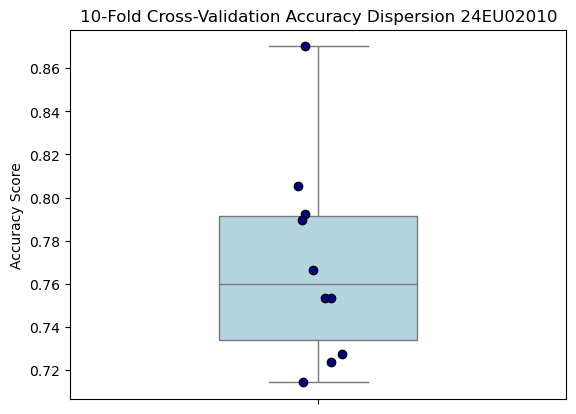

In [33]:
sns.boxplot(y=cv_scores, color='lightblue', width=0.4)
sns.stripplot(y=cv_scores, color='darkblue', size=6, jitter=0.05, edgecolor='black', linewidth=1)
plt.title("10-Fold Cross-Validation Accuracy Dispersion 24EU02010")
plt.ylabel("Accuracy Score")
plt.show()

In [34]:
# Compile comparison table
validation_comparison = pd.DataFrame({
    'Validation Strategy': ['Holdout Stratified (80/20 Split)', '10-Fold Stratified Cross-Validation (Mean)'],
    'Accuracy Score (%)': [holdout_accuracy * 100, cv_scores.mean() * 100],
    'Score Std Deviation (%)': [0.0, cv_scores.std() * 100]
})



In [35]:
print("--- Validation Strategy Trade-offs ---")



--- Validation Strategy Trade-offs ---


In [36]:
print(validation_comparison.to_string(index=False))

                       Validation Strategy  Accuracy Score (%)  Score Std Deviation (%)
          Holdout Stratified (80/20 Split)           75.974026                 0.000000
10-Fold Stratified Cross-Validation (Mean)           76.949761                 4.448026


In [37]:
import warnings


In [38]:
warnings.filterwarnings("ignore")



In [39]:
import pandas as pd


In [40]:
from sklearn.model_selection import train_test_split


In [41]:
from sklearn.preprocessing import StandardScaler



In [42]:
# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"


In [43]:
sonar_features = [f"F_{i}" for i in range(1, 61)]


In [44]:
sonar_columns = sonar_features + ['Class']


In [45]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)



In [46]:
# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})



In [47]:
X_sonar = sonar_df[sonar_features]


In [48]:
y_sonar = sonar_df['Class_numeric']



In [49]:
# Scale features
scaler_sonar = StandardScaler()


In [50]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)



In [51]:
# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)



In [52]:
print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [53]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


In [54]:
from sklearn.svm import SVC


In [55]:
from sklearn.metrics import accuracy_score



In [56]:
# Train baseline SVM classifier with default settings
svm_default = SVC(probability=True, random_state=42)


In [57]:
svm_default.fit(X_train_s, y_train_s)



,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [58]:
# Evaluate baseline accuracy
default_preds = svm_default.predict(X_test_s)


In [59]:
default_accuracy = accuracy_score(y_test_s, default_preds)



In [60]:
print(f"Default SVM Test Accuracy: {default_accuracy * 100:.2f}%")

Default SVM Test Accuracy: 84.13%


In [61]:
from sklearn.model_selection import GridSearchCV



In [62]:
# Define parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}



In [63]:
# Run Grid Search Cross-Validation
grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_s, y_train_s)



,estimator,SVC(probabili...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [64]:
# Extract optimized model and predict
best_svm_grid = grid_search.best_estimator_


In [65]:
grid_preds = best_svm_grid.predict(X_test_s)


In [66]:
grid_accuracy = accuracy_score(y_test_s, grid_preds)



In [67]:
print("Optimal Hyperparameters Selected via Grid Search:", grid_search.best_params_)


Optimal Hyperparameters Selected via Grid Search: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [68]:
print(f"Grid-Search Optimized SVM Test Accuracy: {grid_accuracy * 100:.2f}%")

Grid-Search Optimized SVM Test Accuracy: 92.06%


In [69]:
from sklearn.model_selection import RandomizedSearchCV



In [70]:
# Define parameter distributions
param_distributions = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}



In [71]:
# Run Randomized Search Cross-Validation (evaluating 10 random candidates)
random_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_s, y_train_s)



,estimator,SVC(probabili...ndom_state=42)
,param_distributions,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf']}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [72]:
# Extract optimized model and predict
best_svm_random = random_search.best_estimator_


In [73]:
random_preds = best_svm_random.predict(X_test_s)


In [74]:
random_accuracy = accuracy_score(y_test_s, random_preds)



In [75]:
print("Optimal Hyperparameters Selected via Randomized Search:", random_search.best_params_)



Optimal Hyperparameters Selected via Randomized Search: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}


In [76]:
print(f"Randomized-Search Optimized SVM Test Accuracy: {random_accuracy * 100:.2f}%")


Randomized-Search Optimized SVM Test Accuracy: 79.37%


In [77]:
import matplotlib.pyplot as plt


In [78]:
import seaborn as sns



In [79]:
# Compile results
optimization_results = pd.DataFrame({
    'Tuning Strategy': ['Default Parameters SVM', 'Grid-Search Optimized SVM', 'Randomized-Search Optimized SVM'],
    'Test Accuracy (%)': [default_accuracy * 100, grid_accuracy * 100, random_accuracy * 100]
})



In [80]:
print("--- Hyperparameter Optimization Comparison ---")


--- Hyperparameter Optimization Comparison ---


In [81]:
print(optimization_results.to_string(index=False))



                Tuning Strategy  Test Accuracy (%)
         Default Parameters SVM          84.126984
      Grid-Search Optimized SVM          92.063492
Randomized-Search Optimized SVM          79.365079


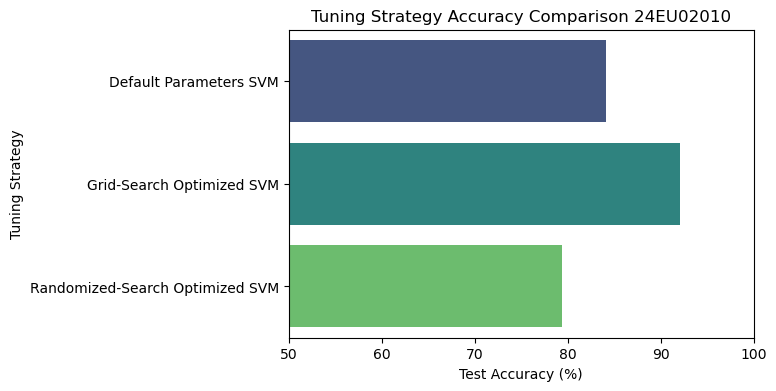

In [82]:
# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=optimization_results, x='Test Accuracy (%)', y='Tuning Strategy', palette='viridis')
plt.xlim([50, 100])
plt.title("Tuning Strategy Accuracy Comparison 24EU02010")
plt.show()

In [83]:
import warnings


In [84]:
warnings.filterwarnings("ignore")



In [85]:
import pandas as pd


In [86]:
import numpy as np


In [87]:
from sklearn.model_selection import train_test_split


In [88]:
from sklearn.pipeline import Pipeline


In [89]:
from sklearn.impute import SimpleImputer


In [90]:
from sklearn.preprocessing import StandardScaler


In [91]:
from sklearn.svm import SVC



In [92]:
# Reload the raw Pima Indians dataset with invalid zero entries intact
pima_raw_df = pd.read_csv(pima_url, header=None, names=pima_cols)



In [93]:
# Using .copy() prevents standard Pandas SettingWithCopyWarnings
X_raw_p = pima_raw_df[pima_cols[:-1]].copy()


In [94]:
y_raw_p = pima_raw_df['Outcome']



In [95]:
# Mark invalid zeros as NaN placeholders for pipeline imputation
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [96]:
X_raw_p[cols_to_impute] = X_raw_p[cols_to_impute].replace(0, np.nan)



In [97]:
# Stratified Train-Test Split (80% train, 20% test)
X_train_raw_p, X_test_raw_p, y_train_raw_p, y_test_raw_p = train_test_split(
    X_raw_p, y_raw_p, test_size=0.20, stratify=y_raw_p, random_state=42
)



In [98]:
# Construct Pipeline with class_weight='balanced' to handle minority class penalty
ml_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('classifier', SVC(probability=True, class_weight='balanced', random_state=42)) 
])



In [99]:
print("Cost-sensitive balanced Pipeline constructed successfully.")

Cost-sensitive balanced Pipeline constructed successfully.


In [100]:
from sklearn.model_selection import GridSearchCV



In [101]:
# We search through a range of parameters to find the optimal decision boundary
pipeline_param_grid = {
    'imputer__strategy': ['mean', 'median'],          
    'classifier__C': [0.1, 1, 5, 10, 50],               
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1] 
}



In [102]:
# Run Grid Search over the pipeline object
pipeline_cv = GridSearchCV(estimator=ml_pipeline, param_grid=pipeline_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)


In [103]:
pipeline_cv.fit(X_train_raw_p, y_train_raw_p)



,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.1, 1, ...], 'classifier__gamma': ['scale', 'auto', ...], 'imputer__strategy': ['mean', 'median']}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [104]:
# Extract optimized pipeline model
best_pipeline = pipeline_cv.best_estimator_



In [105]:
print("Optimal Pipeline Hyperparameters Selected:")


Optimal Pipeline Hyperparameters Selected:


In [106]:
print(pipeline_cv.best_params_)

{'classifier__C': 1, 'classifier__gamma': 0.01, 'imputer__strategy': 'median'}


In [107]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [108]:
import seaborn as sns


In [109]:
import matplotlib.pyplot as plt



In [110]:
# Generate test predictions directly from raw data
pipeline_preds = best_pipeline.predict(X_test_raw_p)


In [111]:
pipeline_accuracy = accuracy_score(y_test_raw_p, pipeline_preds)



In [112]:
print(f"End-to-End Pipeline Test Accuracy: {pipeline_accuracy * 100:.2f}%\\n")


End-to-End Pipeline Test Accuracy: 74.03%\n


In [113]:
print("--- Classification Report (Observe the improved Class 1 metrics) ---")


--- Classification Report (Observe the improved Class 1 metrics) ---


In [114]:
print(classification_report(y_test_raw_p, pipeline_preds))



              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



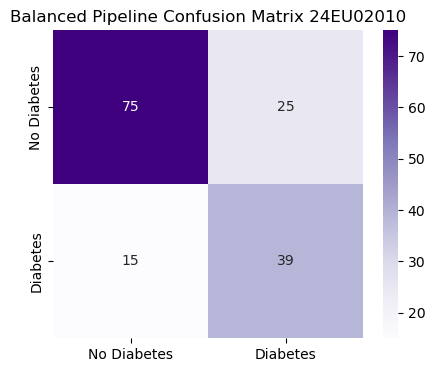

In [115]:
# Plot confusion matrix
cm_pipeline = confusion_matrix(y_test_raw_p, pipeline_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pipeline, annot=True, fmt='d', cmap='Purples', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Balanced Pipeline Confusion Matrix 24EU02010")
plt.show()

In [116]:
import joblib



In [117]:
# Serialize pipeline object to disk
saved_filename = "pima_diabetes_pipeline.joblib"


In [118]:
joblib.dump(best_pipeline, saved_filename)

['pima_diabetes_pipeline.joblib']

In [119]:

print(f"End-to-End Pipeline successfully serialized and saved to '{saved_filename}'.")


End-to-End Pipeline successfully serialized and saved to 'pima_diabetes_pipeline.joblib'.


In [120]:
# Load pipeline back from disk
deployed_pipeline = joblib.load(saved_filename)




In [121]:
# Mock raw patient record containing missing entries marked as 0 (invalid SkinThickness & Insulin)
raw_patient_record = pd.DataFrame([{
    'Pregnancies': 1,
    'Glucose': 189,
    'BloodPressure': 60,
    'SkinThickness': 0, # Invalid zero: will be converted to NaN and imputed by the pipeline
    'Insulin': 0,       # Invalid zero: will be converted to NaN and imputed by the pipeline
    'BMI': 30.1,
    'DiabetesPedigreeFunction': 0.398,
    'Age': 59
}])



In [122]:
# Convert invalid zeros to NaN for proper imputation
raw_patient_record[cols_to_impute] = raw_patient_record[cols_to_impute].replace(0, np.nan)



In [123]:
# Predict using the re-loaded pipeline
deployed_pred = deployed_pipeline.predict(raw_patient_record)


In [124]:
deployed_probs = deployed_pipeline.predict_proba(raw_patient_record)



In [125]:
print("Deployed Pipeline Prediction Output:")


Deployed Pipeline Prediction Output:


In [126]:
print("Predicted Class Label (0 = No Diabetes, 1 = Diabetes):", deployed_pred[0])


Predicted Class Label (0 = No Diabetes, 1 = Diabetes): 1


In [127]:
print(f"Probability of Diabetes Class: {deployed_probs[0][1]*100:.2f}%")

Probability of Diabetes Class: 77.00%
